# Notebook referente ao exercício 5.2 - Modelagem de sinal de radar

Utilizando o modelo de equação de Claerbout de grande abertura, o campo elétrico $u(x, z) = E_y(x, z)$ na atmosfera sobre a superfície do mar, considerando o domínio de propagação $\Omega = \{(x, z) \mid z \in [0, H], x \in [0, X]\}$, onde:

* $z = H = 200$ m é uma fronteira transparente.
* $z = 0$ é a superfície do mar, na qual a condição de Dirichlet $u = 0$ é imposta.

Satisfaz a seguinte equação:

$$u_{xx} + u_{zz} + k^2(1 + n)u = -\delta(x)Q(z)$$

Onde:
* $k = 2\pi f / c$ (número de onda).
* $f$ é a frequência.
* $c$ é a velocidade da luz no vácuo.
* $n(x, z)$ é o quadrado do índice de refração.
* $Q(z)$ é a diretividade da fonte (uma antena parabólica).

A função $Q(z)$ define a condição inicial $u(0, z) = u_0(z) = Q(z)$:

$$Q(z) = A \frac{k\beta}{2\sqrt{\pi} \log_{10} 2} \exp(-ik\theta_0 z) \exp \left( -\frac{\beta^2}{8 \log_{10} 2} k^2(z - z_0)^2 \right)$$

Com os seguintes parâmetros
* $\theta_0$: ângulo de elevação do feixe.
* $z_0 = 10$ m: altitude da fonte.
* $\beta = 35^\circ$: largura do feixe.

---
As configurações da simulação são as seguintes:
* **Frequência:** $f = 300$ MHz (adotada para acelerar os cálculos).
* **Alcance:** Realizar cálculos para até $X = 20$ km.
* **Ângulos de Teste:** $\theta_0 = 5^\circ, 10^\circ, 20^\circ$.

**Perfil do Índice de Refração $n(z)$:**

$$n(z) = 10^{-5} \times \begin{cases} 0, & \text{if } z \geq 100 \text{ m} \\ -1 + z/100, & \text{if } z \in [0, 100 \text{ m}] \end{cases}$$


Para resolver o problema, vamos considerar apenas a propagação para a direita, de modo que a nossa equação diferencial fique da seguinte maneira,

$$\frac{\partial u}{\partial x}=i\sqrt{k^2(1+n(x,z))+\frac{\partial^2u}{\partial z^2}}$$

e consideramos a condição 

$$u(0,z)=Q(z).$$

Podemos usar a aproximação de Padé(1,1), para o lado direito da nossa equação diferencial, nos deixanco com,

$$\frac{\partial u}{\partial x}=ik\frac{1+\frac{1}{4}(n(x,z)+\frac{1}{k^2}\frac{\partial^2}{\partial z^2})}{1-\frac{1}{4}(n(x,z)+\frac{1}{k^2}\frac{\partial^2}{\partial z^2})}u$$

Para simplificar as contas, vamos considerar
$$\hat{A}=(n(x,z)+\frac{1}{k^2}\frac{\partial^2}{\partial z^2})$$

Partindo dessa equação diferencial, podemos discretizar a malha que contém a nossa função, tomando $u_x=\frac{u_{n+1,j}-u_{n,j}}{\Delta x}$ e $u=\frac{u_{n+1,j}+u_{n,j}}{2}$. Com isso, obtemos

$$[2-\hat{A}/2-i\Delta xk(1+\hat{A}/4)]u_{n+1,j}=[2-\hat{A}/2+i\Delta xk(1+\hat{A}/4)]u_{n,j}$$

Dessa maneira, construímos as matrizes $B$ e $C$ como

$$B=(1-\frac{i\Delta xk}{2})-\frac{1}{4}(1+\frac{i\Delta xk}{2})\hat{X}$$
$$C=(1+\frac{i\Delta xk}{2})-\frac{1}{4}(1-\frac{i\Delta xk}{2})\hat{X}$$

Definimos essas matrizes considerando que a função $n$, que aparece em $\hat{A}$, não depende de $x$, ou seja, $n(z)$ é apenas função de $z$.

Determinamos agora, na malha referente a $z$, a segunda derivada em relação a $z$ que aparece em $\hat{A}$,

$$\frac{\partial^2 u_j}{\partial z^2}=\frac{u_{j+1}-2u_{j}+u_{j-1}}{\Delta z^2}$$

Definindo uma nova variável $\gamma=\frac{1}{k^2\Delta z^2}$, obtemos, que a aplicação de $\hat{A}$ em $u_j$, nos dá o seguinte,

$$\hat{A}u_j=[(n_j-2\gamma)u_j+\gamma (u_{j+1}+u_{j-1})]$$

Desse modo, podemos concluir que $\hat{A}$ é uma matriz tridiagonal, com elemenos da diagonal sendo $n_j-2\gamma$, e diagonais inferior e superior com elementos $\gamma$. Com isso, vemos que a matriz que chegamos $B$ também será tridiagonal, de modo que,

* Diagonal principal:
$$(1-\frac{i\Delta xk}{2})-\frac{1}{4}(1+\frac{i\Delta xk}{2})(n_j-2\gamma)$$
* Diagonais inferiores e superiores:
$$-\frac{1}{4}(1+\frac{i\Delta xk}{2})\gamma$$

E para a matriz $C$, temos 

* Diagonal principal:
$$(1+\frac{i\Delta xk}{2})-\frac{1}{4}(1-\frac{i\Delta xk}{2})(n_j-2\gamma)$$
* Diagonais inferiores e superiores:
$$-\frac{1}{4}(1-\frac{i\Delta xk}{2})\gamma$$

Válidas para os pontos internos $j$, mas não para o bordo. Com a condição de contorno de Dirichlet para $z=0$ para o bordo inferior. Para o bordo superior, podemos extender o domínio em um valor $\delta$ e utilizar uma função $\sigma(z)$ de amortecimento.

Para as derivadas nos pontos que estão acima de H, usaremos uma aprocimação com $\sigma(z)$, tomando $\sigma(z)<<1$,

$$\frac{\partial^2 u_j}{\partial z^2}=(1-2i\sigma(z))\frac{u_{j+1}-2u_j+u_{j-1}}{\Delta z^2} $$

Com isso, para $j$ dentro do limite do PML, se definirmos 

$$S(z)=\frac{1-2i\sigma(z)}{k^2\Delta z^2}$$

obtemos,

$$\hat{A}u_j=\frac{1}{4} [(n_j - 2S(z))u_j + S(z)u_{j+1} + S(z)u_{j-1}]$$

Tomaremos $\sigma(z)=\sigma _{max}(\frac{z-H}{\delta})^3$


In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.sparse import diags

In [2]:
f = 300 * 10**6 #Hz
c =3*10**8 #Hz
k = 2*np.pi*f/c

lamb = c/f
dz = lamb/10 # 10 pontos por comprimento de onda 
dx = 5

beta = np.deg2rad(35) 

theta_0 = np.deg2rad(5)  

z0 = 10.0

Amp = 4.0

In [3]:
H = 200
X = 20*10**3
Delta_pml = 40
Nz = int((H+Delta_pml)/dz)
Nx = int(X/dx)
z_extendido = np.linspace(0,H+Delta_pml, Nz)
x = np.linspace(0, X, Nx)

def n(z):
    n = np.zeros_like(z)
    mask =  z <= 100
    n[mask] = -1 + z[mask]/100
    return n

def Q(z, A, k, beta, theta_0, z0):
    # Constantes e termos iniciais
    log10_2 = np.log10(2)
    
    # Termo de amplitude (coeficiente)
    amplitude = A * (k * beta) / (2 * np.sqrt(np.pi) * log10_2)
    
    # Primeiro termo exponencial: exp(-i * k * theta_0 * z)
    phase_term = np.exp(-1j * k * theta_0 * z)
    
    # Segundo termo exponencial (Gaussiano): exp( - (beta^2 / (8 * log10(2))) * k^2 * (z - z0)^2 )
    gaussian_exponent = - (beta**2 / (8 * log10_2)) * (k**2) * (z - z0)**2
    gaussian_term = np.exp(gaussian_exponent)

    
    return amplitude * phase_term * gaussian_term

def sigma(z, H,DELTA, sigma_amp=10**(-3)):

    sigma = np.zeros_like(z)
    mask = z > H
    sigma[mask] = sigma_amp * (z[mask]-H)/DELTA
    return sigma

In [4]:
def definir_matriz(k, dx, dz, n, sigma):
    J = len(n)

    alpha = 1j * k * dx / 2
    #Como sigma igual a zero para valores dentro do grid, então gamma permance inalterado. 
    gamma = (1- 2j * sigma)/ (k**2 * dz**2)


    diag_A = (
        (1 - alpha)
        - 0.25 * (1 + alpha) * n
        + 0.5 * (1 + alpha) * gamma
    )

    diag_cima_A = -0.25 * (1 + alpha) * gamma[:-1] * np.ones(J-1, dtype=complex)
    diag_baixo_A = -0.25 * (1 + alpha) * gamma[1:] * np.ones(J-1, dtype=complex)


    diag_A[0] = 1.0
    diag_A[-1] =1.0
    diag_cima_A[0] = 0.0
    diag_baixo_A[-1] =0.0

    A = diags(
        [diag_baixo_A, diag_A, diag_cima_A],
        [-1, 0, 1],
        format="csc"
    )



    diag_C = (
        (1 + alpha)
        - 0.25 * (1 - alpha) * n
        + 0.5 * (1 - alpha) * gamma
    )

    diag_cima_C = -0.25 * (1 - alpha) * gamma[:-1] * np.ones(J-1, dtype=complex)
    diag_baixo_C = -0.25 * (1 - alpha) * gamma[:1] * np.ones(J-1, dtype=complex)

 
    diag_C[0] = 1.0
    diag_C[-1] = 1.0
    diag_cima_C[0] = 0.0
    diag_baixo_C[-1] = 0.0

    C = diags(
        [diag_baixo_C, diag_C, diag_cima_C],
        [-1, 0, 1],
        format="csc"
    )



    A_info = {
        "matriz_esparsa": A,
        "diag_cima": diag_cima_A,
        "diag": diag_A,
        "diag_baixo": diag_baixo_A
    }

    C_info = {
        "matriz_esparsa": C,
        "diag_cima": diag_cima_C,
        "diag": diag_C,
        "diag_baixo": diag_baixo_C
    }

    return A_info, C_info
ni = n(z_extendido)
sigmai = sigma(z =z_extendido, H=H, DELTA=Delta_pml)
A2_info,C2_info = definir_matriz(k=k, dx= dx, dz=dz, n=ni, sigma=sigmai)
A2_info["matriz_esparsa"].shape

(2400, 2400)

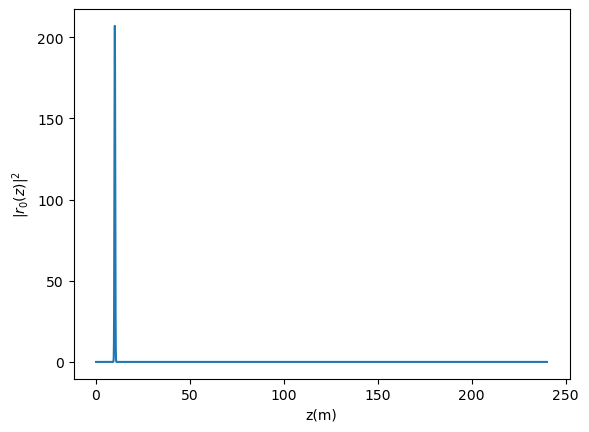

In [11]:
r_0 = Q(z=z_extendido,A=Amp,k=k, beta=beta, theta_0=theta_0, z0= z0)
plt.plot(z_extendido, np.abs(r_0)**2)
plt.xlabel("z(m)")
plt.ylabel('$|r_0(z)|^2$')
plt.show()

In [ ]:
def thomas(subd, supd, diag, u_n):

    N = len(u_n)

    # Cópias para não modificar os originais
    c_ = np.zeros(N-1, dtype=complex)
    d_ = np.zeros(N,   dtype=complex)
    x  = np.zeros(N,   dtype=complex)

    # --- Forward sweep ---
    c_[0] = supd[0] / diag[0]
    d_[0] = u_n[0] / diag[0]

    for i in range(1, N):
        denom = diag[i] - subd[i-1] * c_[i-1]
        d_[i] = (u_n[i] - subd[i-1] * d_[i-1]) / denom
        if i < N-1:
            c_[i] = supd[i] / denom


    x[-1] = d_[-1]
    for i in range(N-2, -1, -1):
        x[i] = d_[i] - c_[i] * x[i+1]

    return x

In [9]:
def operar(A_info,C, r_n):
    A_cima = A_info["diag_cima"]
    A_baixo = A_info["diag_baixo"]
    A_meio = A_info["diag"]

    y = C@r_n
    r_n_mais_1 = thomas(A_cima, A_baixo,A_meio, y )
    return r_n_mais_1


def evolucao_completa(A_info, C, r0, n_x):

    J = len(r0)
    R = np.zeros((n_x, J), dtype=complex)
    R[0] = r0.astype(complex)
    
    r_atual = R[0].copy()
    
    for n in range(1,n_x):
        r_atual = operar(A_info=A_info, C=C, r_n=r_atual)
        R[n] = r_atual
    
    return R

In [10]:
theta_01 = np.deg2rad(5)
r_0_theta1 = Q(z=z_extendido,A=Amp,k=k, beta=beta, theta_0=theta_01, z0= z0)
R2theta1 = evolucao_completa(A_info=A2_info, C= C2_info["matriz_esparsa"], r0=r_0_theta1, n_x=Nx)
modulos = np.abs(R2theta1)
modulos = modulos.T

/tmp/ipykernel_9861/2006097970.py:28: RuntimeWarning: invalid value encountered in scalar multiply
  d_[i] = (u_n[i] - subd[i-1] * d_[i-1]) / denom
